In [1]:
# Notebooks run from the notebooks folder, so the src folder is added to the path.
import sys
from pathlib import Path

src_folder = Path.cwd().parent / "src"
sys.path.insert(0, str(src_folder))

In [2]:
# Reloads edited modules in src without restarting the kernel.
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config

Tile is 10013 x 12760 pixels


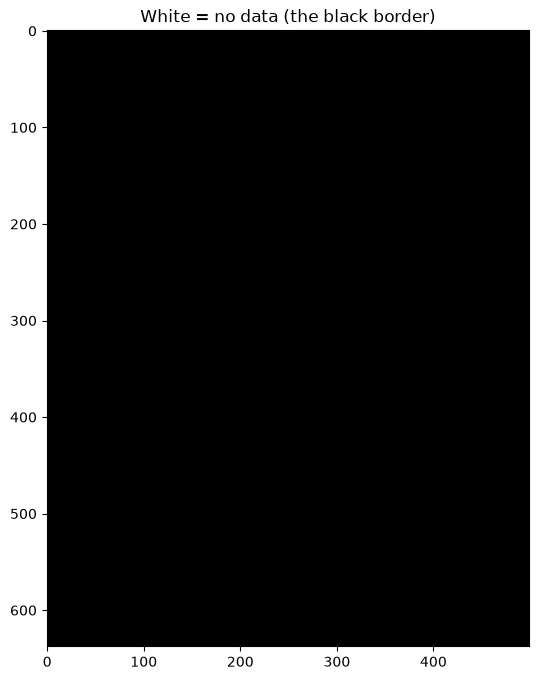

In [4]:
photo = rasterio.open(config.NAIP_FILE)
print("Tile is", photo.width, "x", photo.height, "pixels")

# A low resolution read of the full tile shows the extent of the nodata border.
small_version = photo.read(
    1,
    out_shape=(photo.height // 20, photo.width // 20),
)
photo.close()

plt.figure(figsize=(8, 8))
plt.imshow(small_version == 0, cmap="gray")
plt.title("White = no data (the black border)")
plt.show()

In [5]:
photo = rasterio.open(config.NAIP_FILE)
test_read = photo.read(window=config.STUDY_AREA)
photo.close()

brightness = test_read.sum(axis=0)
fraction_black = (brightness == 0).mean()

print("Fraction of the study area that is black:", round(fraction_black, 4))

if fraction_black > 0.001:
    print("Too much black - pull the edges in.")
else:
    print("Clear of the border.")

# Study area dimensions in kilometers.
width_km = config.STUDY_AREA.width * 0.6 / 1000
height_km = config.STUDY_AREA.height * 0.6 / 1000
print("Study area:", round(width_km, 1), "x", round(height_km, 1), "km")

Fraction of the study area that is black: 0.0
Clear of the border.
Study area: 6.0 x 7.7 km


In [6]:
import prepare

canopy_mask, landcover = prepare.align_labels()

Fraction of the study area that is canopy: 0.245


Zooming in at row 10800 col 5600


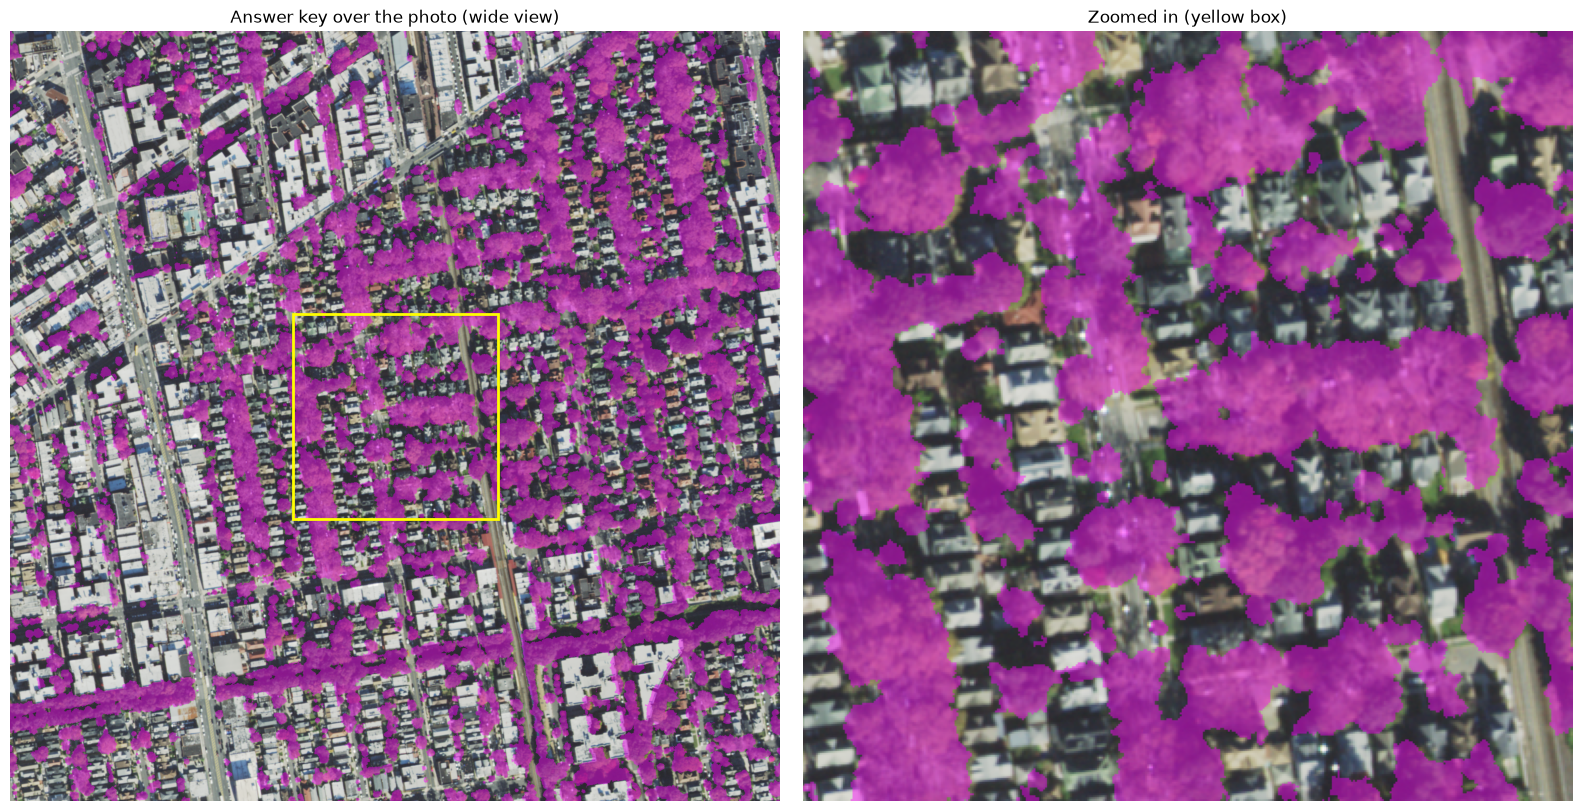

In [12]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from rasterio.windows import Window

WIDE_SIZE = 1500
ZOOM_SIZE = 400

# 1. Locate an area of approximately 40% canopy, where edges reveal any shift.
TARGET_FRACTION = 0.5    # Adjust to inspect a different area.

best_row = 0
best_col = 0
best_difference = 1.0

mask_height = canopy_mask.shape[0]
mask_width = canopy_mask.shape[1]

for row in range(0, mask_height - ZOOM_SIZE + 1, ZOOM_SIZE):
    for col in range(0, mask_width - ZOOM_SIZE + 1, ZOOM_SIZE):
        window_of_mask = canopy_mask[row:row + ZOOM_SIZE, col:col + ZOOM_SIZE]
        fraction = window_of_mask.mean()
        difference = abs(fraction - TARGET_FRACTION)

        if difference < best_difference:
            best_difference = difference
            best_row = row
            best_col = col

print("Zooming in at row", best_row, "col", best_col)

# 2. Center the wide view on that area.
center_row = best_row + ZOOM_SIZE // 2
center_col = best_col + ZOOM_SIZE // 2

wide_row = center_row - WIDE_SIZE // 2
wide_col = center_col - WIDE_SIZE // 2

# The view is constrained to the study area.
wide_row = max(0, min(wide_row, mask_height - WIDE_SIZE))
wide_col = max(0, min(wide_col, mask_width - WIDE_SIZE))

# 3. Read only this section, as reading the full area is slow.
photo = rasterio.open(config.NAIP_FILE)
wide_window = Window(
    config.STUDY_AREA.col_off + wide_col,
    config.STUDY_AREA.row_off + wide_row,
    WIDE_SIZE,
    WIDE_SIZE,
)
wide_photo = photo.read([1, 2, 3], window=wide_window)
photo.close()

wide_labels = canopy_mask[wide_row:wide_row + WIDE_SIZE, wide_col:wide_col + WIDE_SIZE]

# Position of the zoomed area within the wide view.
zoom_row_in_wide = best_row - wide_row
zoom_col_in_wide = best_col - wide_col

zoom_photo = wide_photo[
    :,
    zoom_row_in_wide:zoom_row_in_wide + ZOOM_SIZE,
    zoom_col_in_wide:zoom_col_in_wide + ZOOM_SIZE,
]
zoom_labels = canopy_mask[best_row:best_row + ZOOM_SIZE, best_col:best_col + ZOOM_SIZE]

# 4. Plot, reordering the axes from (band, row, col) to (row, col, band).
wide_for_display = np.transpose(wide_photo, (1, 2, 0))
zoom_for_display = np.transpose(zoom_photo, (1, 2, 0))

# Non-canopy pixels are masked so only the canopy is shaded.
wide_canopy_only = np.ma.masked_where(wide_labels == 0, wide_labels)
zoom_canopy_only = np.ma.masked_where(zoom_labels == 0, zoom_labels)

# Magenta is used because it does not occur naturally in the imagery.
canopy_color = ListedColormap(["#ff00ff"])

figure, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(wide_for_display)
axes[0].imshow(wide_canopy_only, cmap=canopy_color, alpha=0.45)
axes[0].set_title("Answer key over the photo (wide view)")

# Outline of the zoomed area.
zoom_box = Rectangle(
    (zoom_col_in_wide, zoom_row_in_wide),   # Order is (column, row)
    ZOOM_SIZE,
    ZOOM_SIZE,
    fill=False,
    edgecolor="yellow",
    linewidth=2,
)
axes[0].add_patch(zoom_box)

axes[1].imshow(zoom_for_display)
axes[1].imshow(zoom_canopy_only, cmap=canopy_color, alpha=0.45)
axes[1].set_title("Zoomed in (yellow box)")

axes[0].axis("off")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(config.FIGURES_FOLDER / "01_alignment_check.png", dpi=120, bbox_inches="tight")
plt.show()

Alignment shows generally good overlap between land cover canopy classification and aerial imagery. Tree crowns are starting to turn orange in the imagery which may affect measurements further on. Some canopy cover also appears to be missing in the imagery, which could mean the trees were trimmed or cut down.

In [14]:
prepare.cut_chips(landcover)

Saved 1911 tiles. Skipped 0 (incomplete tile data).
